In [650]:
import yaml
import numpy as np
import os
import pandas as pd
import random
from pathlib import Path
from src.data_pipeline import segment_signal, perform_fft_on_segments, create_metadata_df, load_measurement
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.signal import resample, find_peaks, butter, filtfilt
from scipy.stats import Normal
from typing import Tuple, List
from tqdm.auto import tqdm
from sklearn.manifold import TSNE

In [651]:
SEED = 0xDEAD
np.random.seed(SEED)
random.seed(SEED)

In [652]:
def interpolate_canonical(
    spectra: np.ndarray,
    freqs: np.ndarray,
    f_cut: float,
    f_out: int,
) -> Tuple[np.ndarray, np.ndarray]:
    if spectra.ndim != 2:
        raise ValueError("`spectra` must be 2-D (N, F)")
    if freqs.ndim != 1:
        raise ValueError("`freqs` must be 1-D (F,)")
    if spectra.shape[1] != freqs.size:
        raise ValueError("Dimension mismatch between `spectra` and `freqs`")
    f_star = np.linspace(0.0, f_cut, f_out, endpoint=False, dtype=np.float32)
    out = np.empty((spectra.shape[0], f_out), dtype=np.float32)
    for i, row in enumerate(spectra):
        out[i] = np.interp(f_star, freqs, row).astype(np.float32)
    return out, f_star

In [653]:
state2name = {
    1: "rotor bar defect",
    2: "normal",
    3: "bearing defect",
    4: "inter-turn short circuits"
}
base_dir = "../dataset/engine_2"
path2metadata = os.path.join(base_dir, 'metadata.csv')
if os.path.isfile(path2metadata):
    metadata_df = pd.read_csv(os.path.join(path2metadata))
    metadata_df.set_index('measurement_id', inplace=True)
else:
    metadata_df = create_metadata_df(base_dir, state2name)
    metadata_df.to_csv(path2metadata)
real_df = metadata_df[(metadata_df.state == 'normal') & (metadata_df.load_condition == 100)]
real_df.head()

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727791012_1,1727791012,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791211_1,1727791211,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727790910_1,1727790910,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727790870_1,1727790870,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791170_1,1727791170,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml


In [654]:
simulated_files = list(map(str, Path('../Faulty_AC_motor_001').glob('nofault_*.csv')))
simulated_df = pd.DataFrame({'file_path': simulated_files})

def get_phase(x):
    phase = x.split('\\')[2].split('_')[-1].split('.')[0]
    return 1 if phase == 'phaseA' else 2 if phase == 'phaseB' else 3

def get_num_observations(x):
    return pd.read_csv(x).shape[0]

def get_measurement_id(x):
    return f'{x.state}_{x.phase}'

simulated_df['state'] = 'normal'
simulated_df['load_condition'] = 100
simulated_df['experiment'] = 'experiment_2'
simulated_df['phase'] = simulated_df.file_path.apply(get_phase)
simulated_df['num_observations'] = simulated_df.file_path.apply(get_num_observations)
simulated_df['measurement_id'] = simulated_df.apply(get_measurement_id, axis=1)
simulated_df = simulated_df.reset_index(drop=True).set_index('measurement_id')
simulated_df.head()

,file_path,state,load_condition,experiment,phase,num_observations
measurement_id,,,,,,
normal_1,..\Faulty_AC_motor_001\nofault_load100_phaseA.csv,normal,100,experiment_2,1,16666
normal_2,..\Faulty_AC_motor_001\nofault_load100_phaseB.csv,normal,100,experiment_2,2,16666
normal_3,..\Faulty_AC_motor_001\nofault_load100_phaseC.csv,normal,100,experiment_2,3,16666


In [655]:
p = 1 # it works the same for all phases
real_measurement = f'1727790910_{p}' 
sim_measurement = f'normal_{p}'

real_norm_df = load_measurement(real_measurement, real_df)
#real_norm_const = real_norm_df.Current.mean()
#real_norm_df.Current = real_norm_df.Current - real_norm_const
sim_norm_df = load_measurement(sim_measurement, simulated_df)
sim_norm_df.index = sim_norm_df.index * 1000

In [656]:
with open("../training_configs/train_engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]

num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

batch_size = train_params["data_parameters"]["batch_size"]

normalization_method = train_params["dataset_parameters"]["normalization_method"]

train_params

{'engineLabel': 'engine_2',
 'task': 'binary',
 'model': 'ResNet',
 'test_run': False,
 'comet_online': False,
 'seed': 42,
 'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'db': True,
  'peak_type': 'gaussian',
  'peak_segment': 4,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [0, 20, 40, 60, 80, 100],
  'phases_to_use': [1, 2, 3]},
 'model_parameters': {'attention_module': False, 'dropout': 0.2},
 'training_parameters': {'num_epochs_binary': 30,
  'num_epochs_multi': 30,
  'initial_lr': 0.001,
  'patience': 10},
 'data_parameters': {'batch_size': 4096},
 'dataset_parameters': {'batch_size': 4096,
  'normalization_method': 'min-max',
  'normalization_mode': 'global',
  'real_fault_train': 0,
  'test_size': 0.3,
  'val_size': 0

In [657]:
def tight_plots(ax):
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_single_segment_with_uncertainty(fft_segments, 
                                         x_values=None, 
                                         max_points=1000, 
                                         n_std=2, 
                                         title="Spectrum with Uncertainty",
                                         axis_labels=None, 
                                         highlight_freqs=None, 
                                         method='closest',
                                         inplace=True):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std 

    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = resample(spectrum_mean, max_points)
        spectrum_std = resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = resample(x_values, max_points)
            else:
                x_values = resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )

    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)

    if inplace:
        tight_plots(ax)

    return fig, ax

In [658]:
real_segments = segment_signal(
    real_norm_df['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

print(f'Shape: {real_segments.shape[0]} segments of size {real_segments.shape[1]}')

real_fft, real_freqs = perform_fft_on_segments(
    real_segments, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq
)

Shape: 320 segments of size 10000


In [659]:
max_points = 1000
mean_real_spectrum = np.mean(real_fft, axis=0)
if len(mean_real_spectrum) > max_points:
    mean_real_spectrum = resample(mean_real_spectrum, max_points)
peaks, _ = find_peaks(mean_real_spectrum, height=20)
#peaks = np.insert(peaks, 0, 0)
#peaks

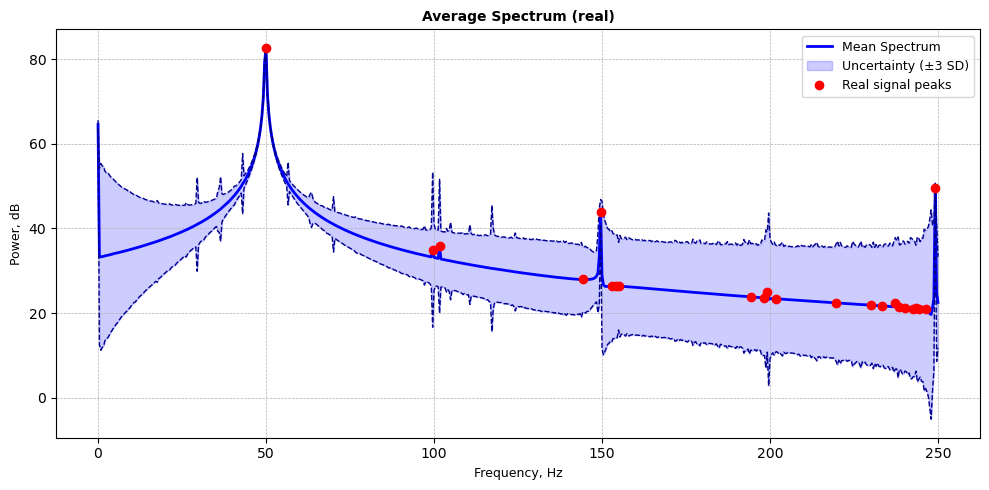

In [660]:
fig, ax = plot_single_segment_with_uncertainty(real_fft, 
                                               x_values=real_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (real)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

In [661]:
sim_segments = segment_signal(
    sim_norm_df['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)
print(f'Shape: {sim_segments.shape[0]} segments of size {sim_segments.shape[1]}')

f_sampling_sim = 12800
sim_fft, sim_freqs = perform_fft_on_segments(
    sim_segments, 
    f_sampling_sim, 
    db=True, 
    cutoff_freq=cutoff_freq
)

resampled_fft, resampled_freqs = interpolate_canonical(sim_fft, sim_freqs, cutoff_freq, len(real_freqs))

Shape: 334 segments of size 10000


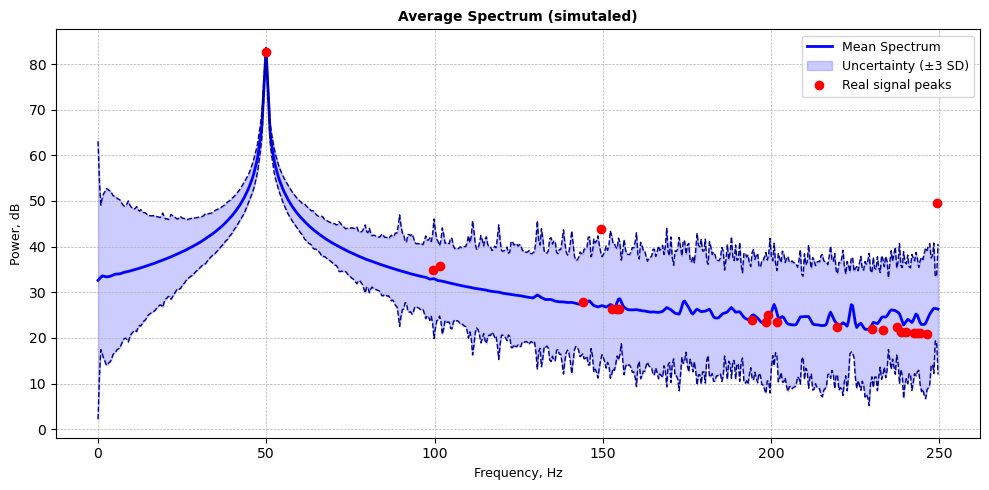

In [662]:
fig, ax = plot_single_segment_with_uncertainty(resampled_fft, 
                                               x_values=resampled_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (simutaled)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

In [663]:
real_fft.shape, resampled_fft.shape

((320, 611), (334, 611))

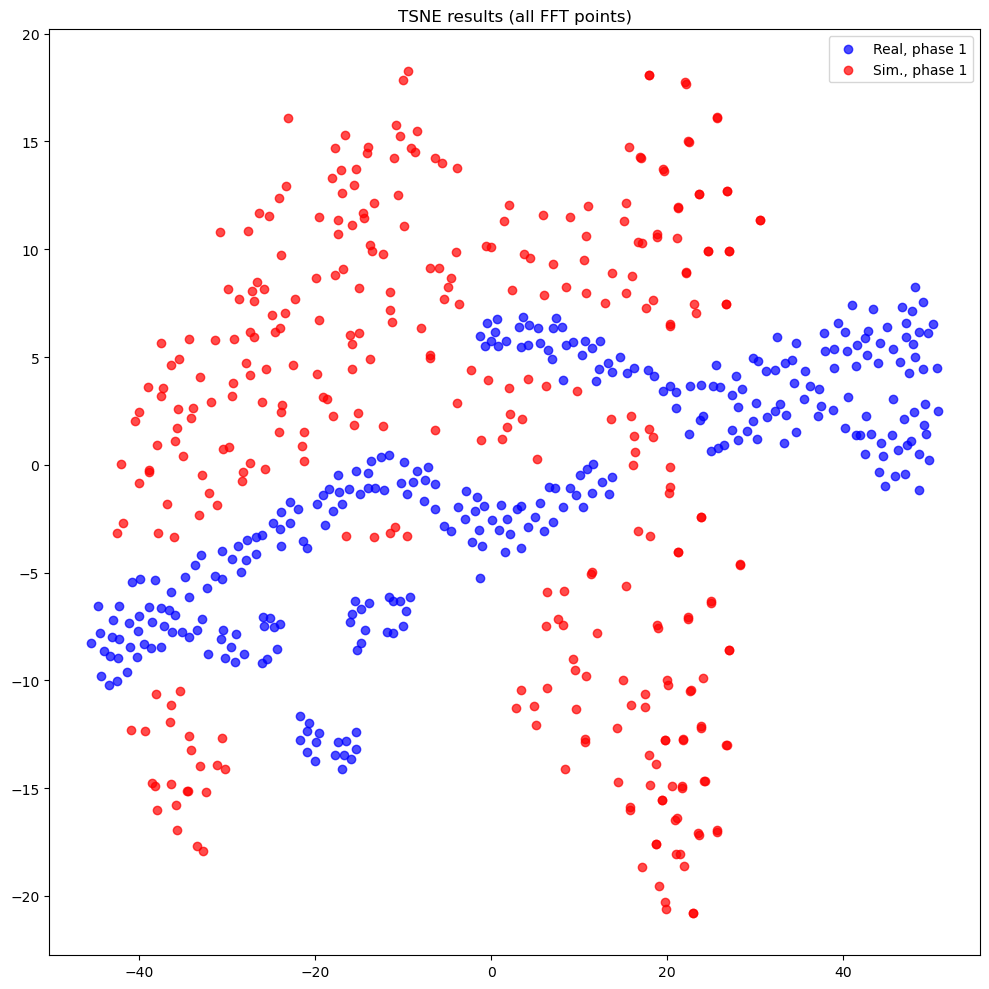

In [664]:
tsne = TSNE(n_components=2)
labels = np.array([0] * real_fft.shape[0] + 
                  [1] * resampled_fft.shape[0])
dots = tsne.fit_transform(np.vstack((real_fft, resampled_fft)))
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], facecolor='b', alpha=0.7, label=f"Real, phase {p}")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], facecolor='r', alpha=0.7, label=f"Sim., phase {p}")
plt.legend()
plt.title('TSNE results (all FFT points)')
plt.tight_layout()
plt.show()

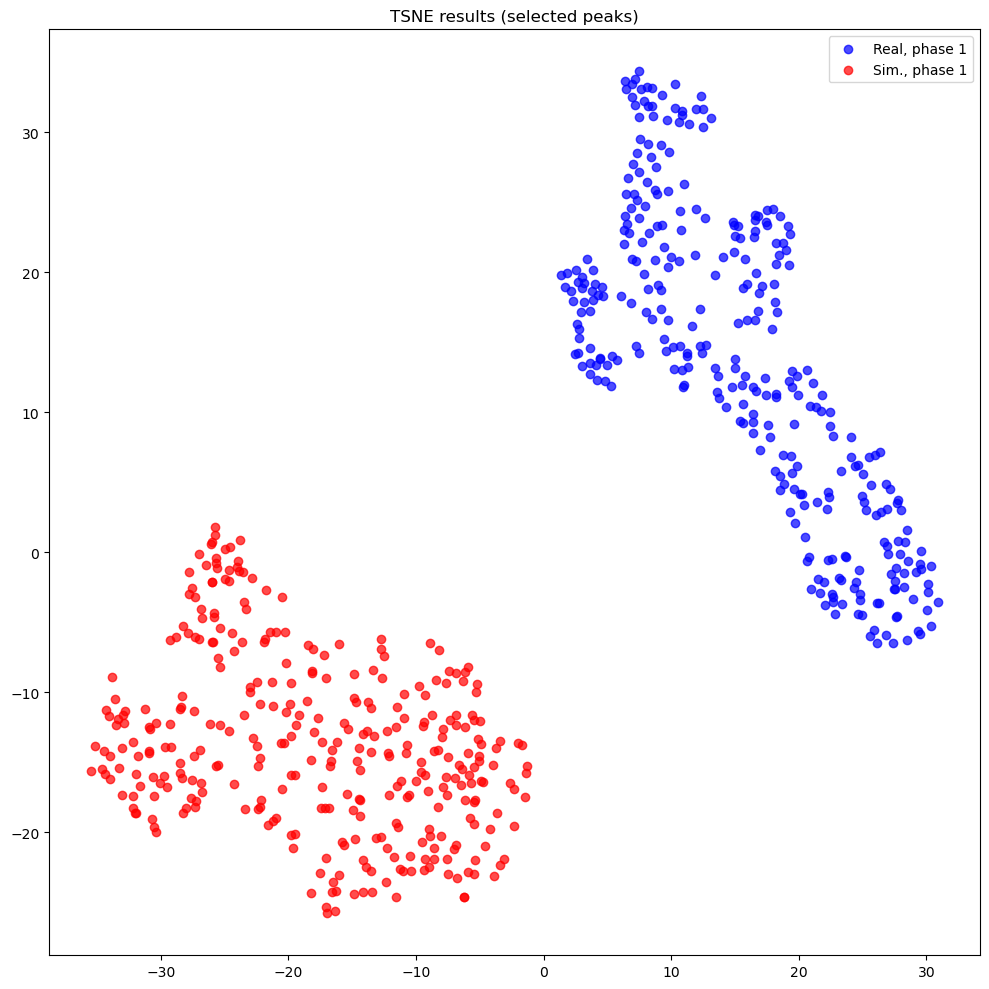

In [665]:
dots = tsne.fit_transform(np.vstack((real_fft, resampled_fft))[:, peaks])
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], facecolor='b', alpha=0.7, label=f"Real, phase {p}")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], facecolor='r', alpha=0.7, label=f"Sim., phase {p}")
plt.legend()
plt.title('TSNE results (selected peaks)')
plt.tight_layout()
plt.show()

In [666]:
sim_norm_df.index[0]

np.float64(0.32)

In [667]:
#sim_norm_df.Current = filtfilt(*butter(4, 0.1), sim_norm_df.Current)

#sim_segments = segment_signal(
#    sim_norm_df['Current'].dropna().values, 
#    segment_length=segment_length, 
#    step=shift, 
#    apply_window=False
#)
#print(f'Shape: {sim_segments.shape[0]} segments of size {sim_segments.shape[1]}')

#sim_fft, sim_freqs = perform_fft_on_segments(
#    sim_segments, 
#    f_sampling_sim, 
#    db=True, 
#    cutoff_freq=cutoff_freq
#)

#resampled_fft, resampled_freqs = interpolate_canonical(sim_fft, sim_freqs, cutoff_freq, len(real_freqs))

#fig, ax = plot_single_segment_with_uncertainty(resampled_fft, 
#                                               x_values=resampled_freqs, 
#                                               n_std=3, 
#                                               title='Average Spectrum (filtered simulated)',
#                                               inplace=False)
#ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
#tight_plots(ax)

In [668]:
resampled_fft_1 = resampled_fft.copy()

for peak in peaks:
    peak_values = real_fft[:, peak]
    peak_dist = Normal(mu=peak_values.mean(), sigma=peak_values.std())
    resampled_fft_1[:, peak] = peak_dist.sample(resampled_fft_1.shape[0])

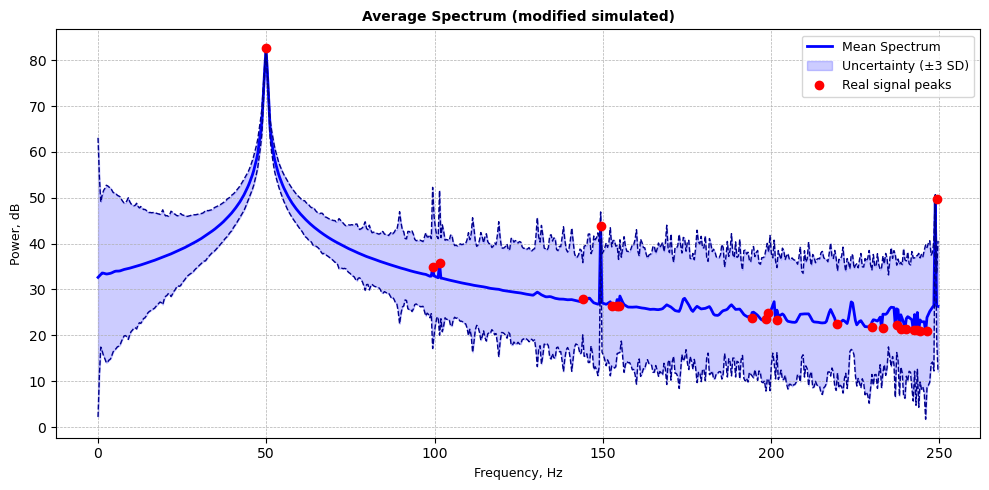

In [669]:
fig, ax = plot_single_segment_with_uncertainty(resampled_fft_1, 
                                               x_values=resampled_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (modified simulated)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

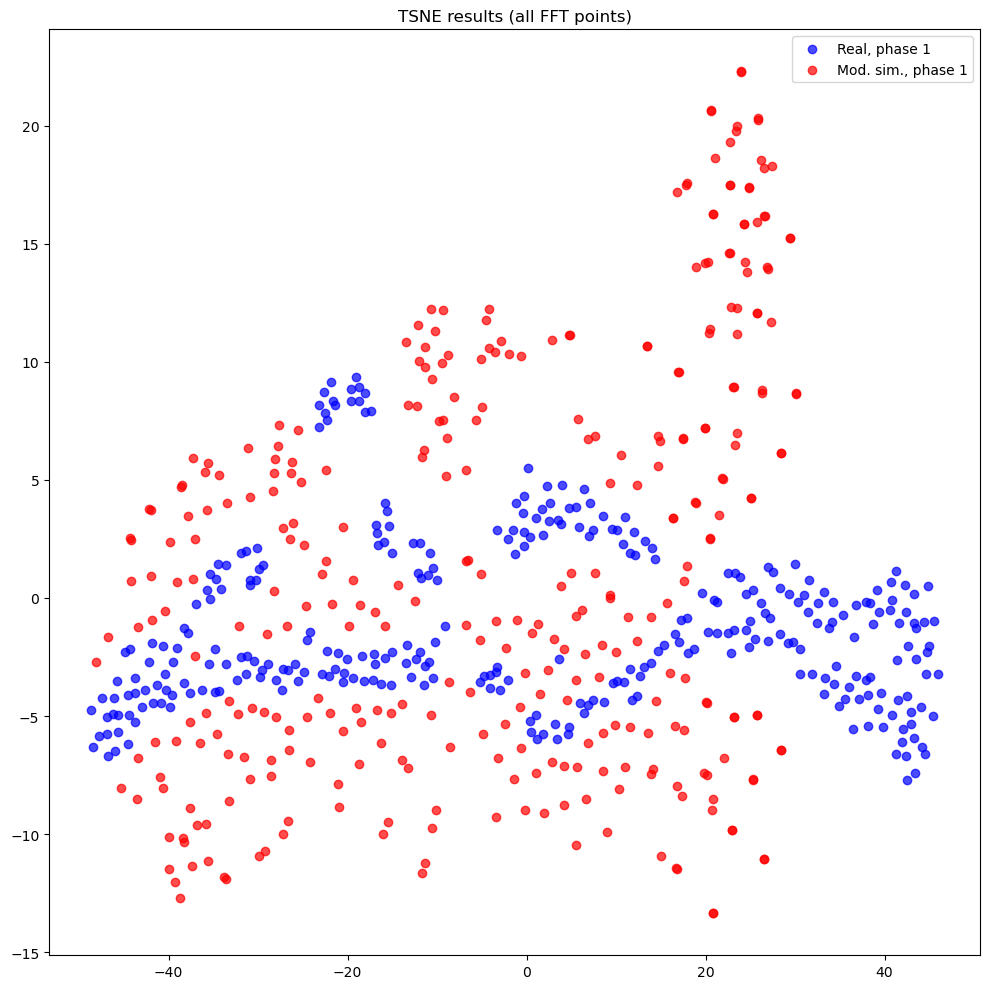

In [670]:
dots = tsne.fit_transform(np.vstack((real_fft, resampled_fft_1)))
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], facecolor='b', alpha=0.7, label=f"Real, phase {p}")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], facecolor='r', alpha=0.7, label=f"Mod. sim., phase {p}")
plt.legend()
plt.title('TSNE results (all FFT points)')
plt.tight_layout()
plt.show()

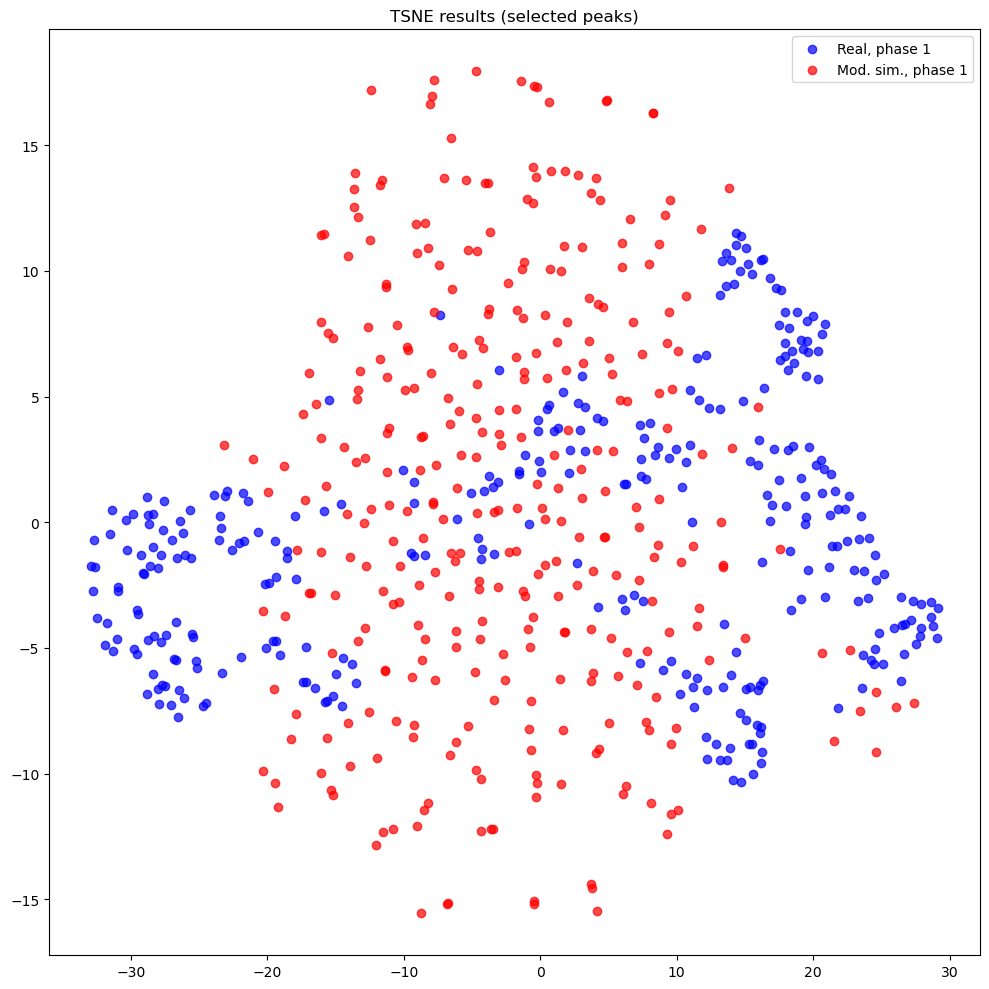

In [671]:
dots = tsne.fit_transform(np.vstack((real_fft, resampled_fft_1))[:, peaks])
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], facecolor='b', alpha=0.7, label=f"Real, phase {p}")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], facecolor='r', alpha=0.7, label=f"Mod. sim., phase {p}")
plt.legend()
plt.title('TSNE results (selected peaks)')
plt.tight_layout()
plt.show()

In [ ]:
resampled_fft_1 = resampled_fft.copy()

threshold = 2
for peak in peaks:
    # it is also useful to add a comparsion with 100 Hz
    if abs(real_freqs[peak] - 150) <= threshold or abs(real_freqs[peak] - 250) <= threshold:
        peak_values = real_fft[:, peak]
        peak_dist = Normal(mu=peak_values.mean(), sigma=peak_values.std())
        resampled_fft_1[:, peak] = peak_dist.sample(resampled_fft_1.shape[0])

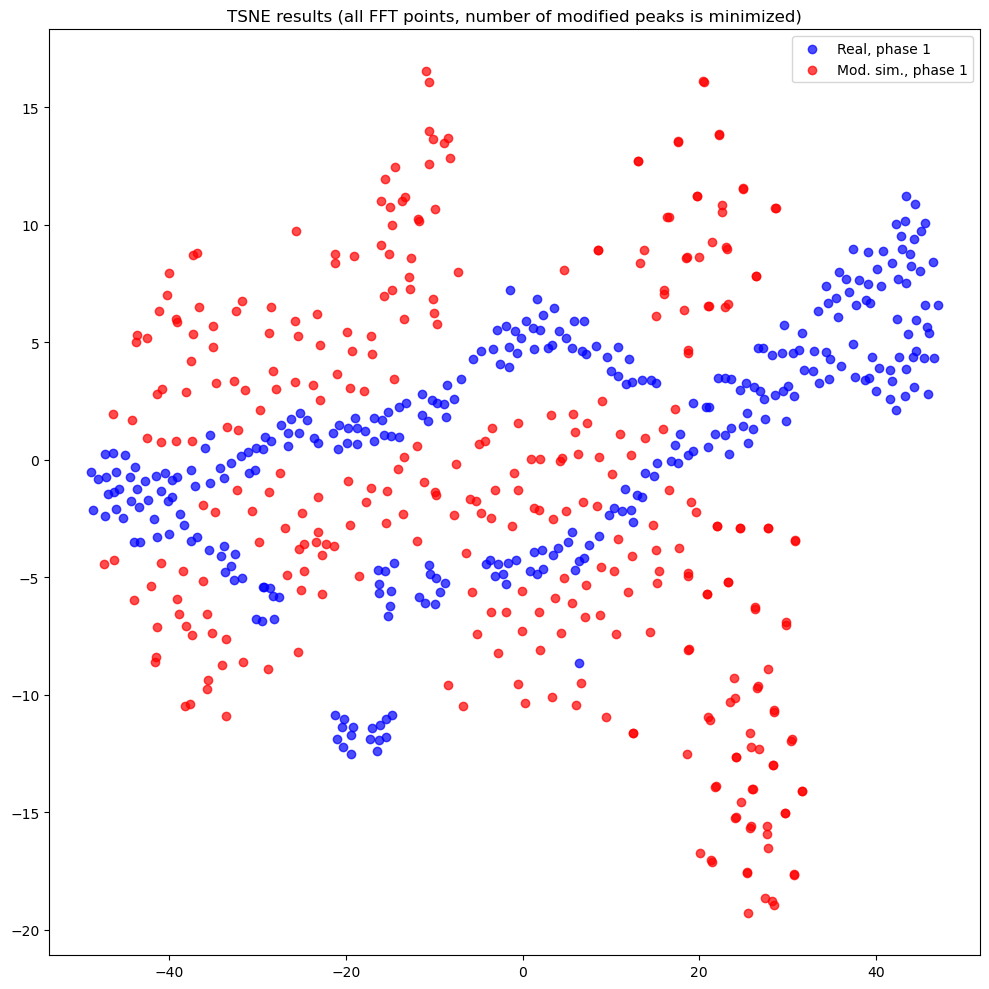

In [673]:
dots = tsne.fit_transform(np.vstack((real_fft, resampled_fft_1)))
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], facecolor='b', alpha=0.7, label=f"Real, phase {p}")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], facecolor='r', alpha=0.7, label=f"Mod. sim., phase {p}")
plt.legend()
plt.title('TSNE results (all FFT points, number of modified peaks is minimized)')
plt.tight_layout()
plt.show()

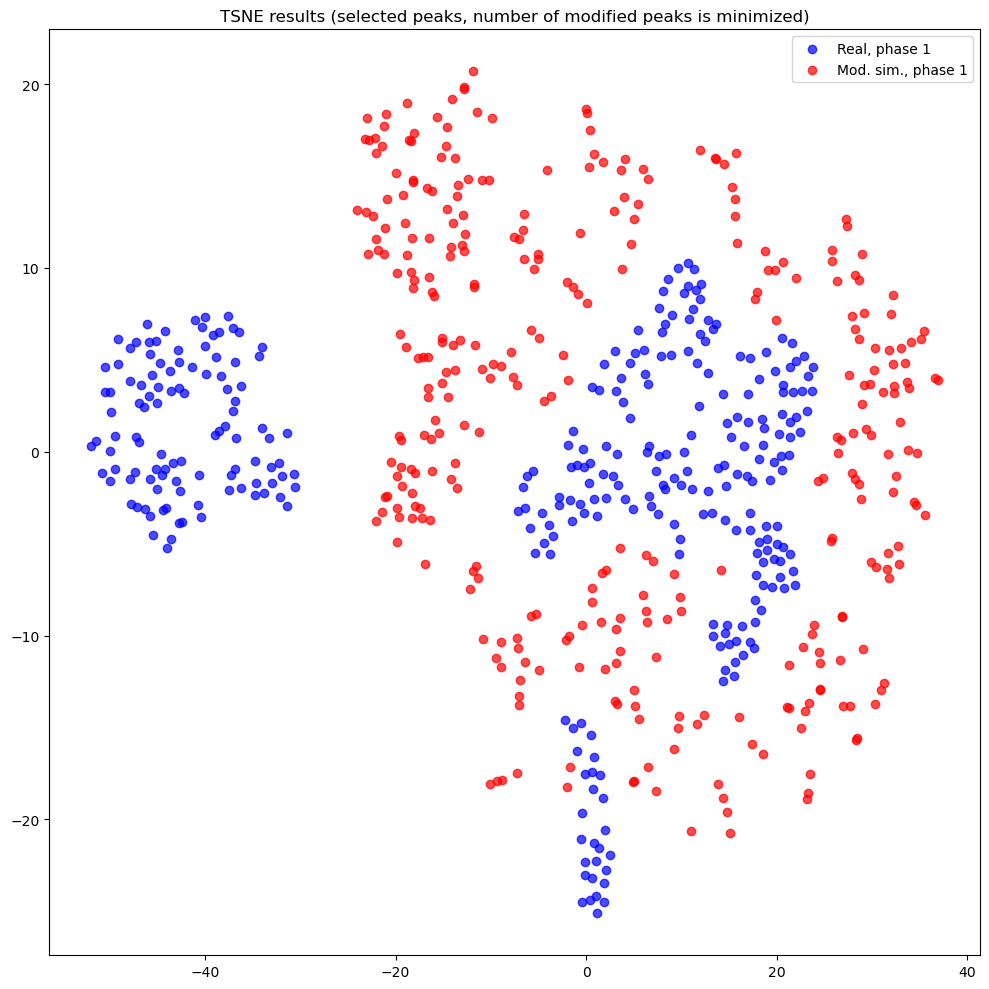

In [674]:
dots = tsne.fit_transform(np.vstack((real_fft, resampled_fft_1))[:, peaks])
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], facecolor='b', alpha=0.7, label=f"Real, phase {p}")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], facecolor='r', alpha=0.7, label=f"Mod. sim., phase {p}")
plt.legend()
plt.title('TSNE results (selected peaks, number of modified peaks is minimized)')
plt.tight_layout()
plt.show()